In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm


### Loading in sensitivity results from the MATLAB script

In [ ]:
df_anova_matlab = pd.read_csv("../data/Photoacoustic_Study/csv/anova_eta2_output.csv", index_col=0)
df_anova_matlab

,Model,GLbins,Wavelength,Reconstruction,Residual
Row,,,,,
original_firstorder_10Percentile,0.483177,2.107099e-31,0.009821,0.120331,0.386672
original_firstorder_90Percentile,0.138880,3.680358e-31,0.006376,0.730335,0.124409
original_firstorder_Energy,0.261040,1.598948e-32,0.016702,0.418610,0.303649
original_firstorder_Entropy,0.008664,9.863630e-01,0.000145,0.003288,0.001541
original_firstorder_InterquartileRange,0.061645,0.000000e+00,0.010514,0.862971,0.064870
...,...,...,...,...,...
original_ngtdm_Busyness,0.008290,9.631874e-01,0.000785,0.000706,0.027032
original_ngtdm_Coarseness,0.642518,2.329893e-01,0.007509,0.062550,0.054433
original_ngtdm_Complexity,0.000019,9.967120e-01,0.000310,0.000108,0.002851


### Plotting full factorial ANOVA

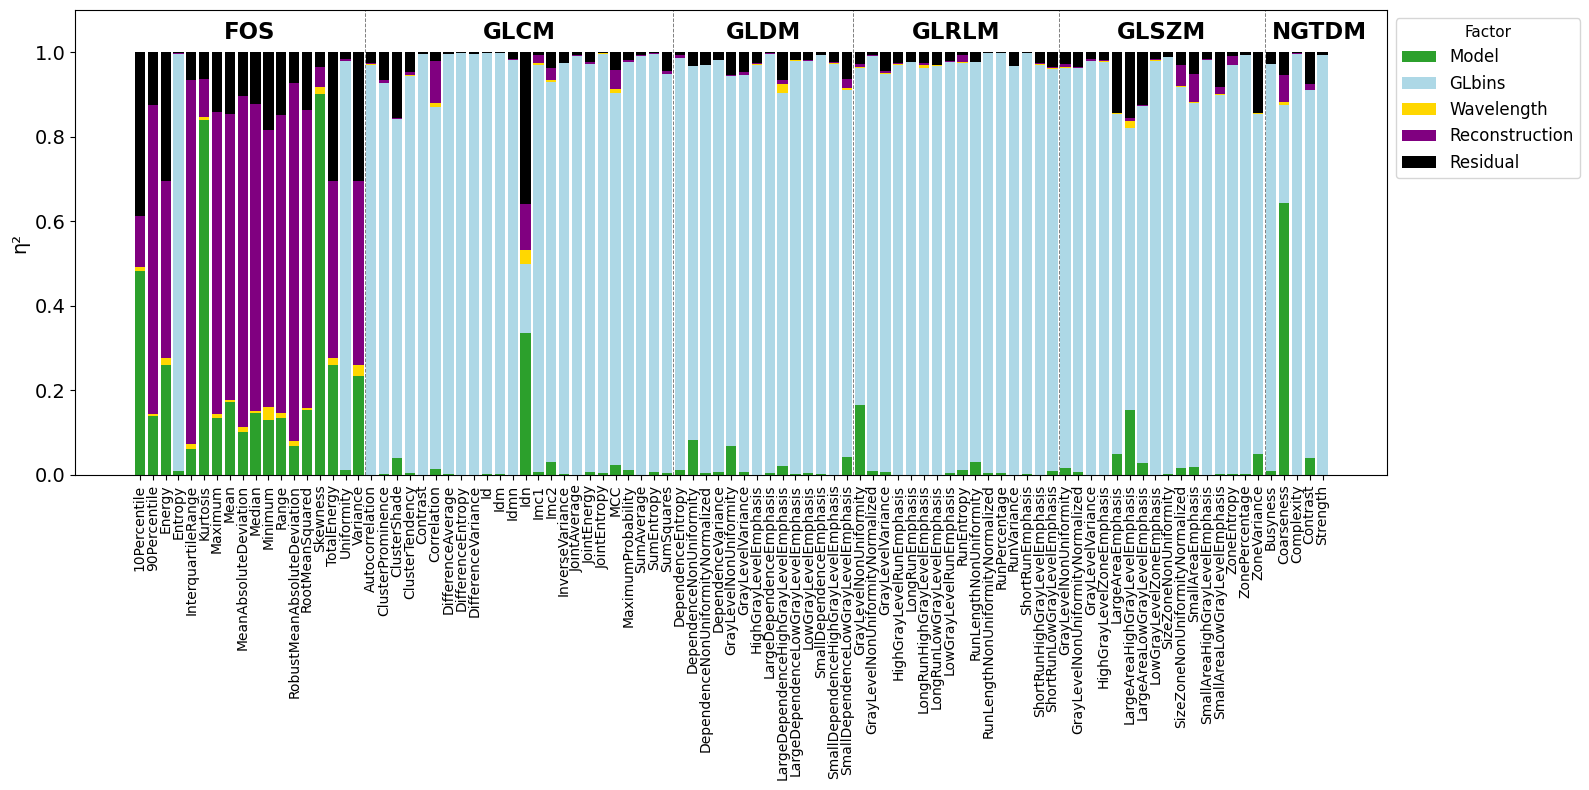

In [14]:
# You already have df_anova_matlab loaded
# Assume df_anova_matlab.index holds your full feature names

# Create mapping functions
def extract_group_and_shortname(feature):
    if 'firstorder' in feature:
        group = 'FOS'
        short = feature.split('firstorder_')[-1]
    elif 'glcm' in feature:
        group = 'GLCM'
        short = feature.split('glcm_')[-1]
    elif 'gldm' in feature:
        group = 'GLDM'
        short = feature.split('gldm_')[-1]
    elif 'glrlm' in feature:
        group = 'GLRLM'
        short = feature.split('glrlm_')[-1]
    elif 'glszm' in feature:
        group = 'GLSZM'
        short = feature.split('glszm_')[-1]
    elif 'ngtdm' in feature:
        group = 'NGTDM'
        short = feature.split('ngtdm_')[-1]
    else:
        group = 'Other'
        short = feature
    return group, short

# Apply to dataframe
df_anova_matlab['Group'], df_anova_matlab['ShortName'] = zip(*df_anova_matlab.index.map(extract_group_and_shortname))

# Sort dataframe by group
df_anova_matlab_sorted = df_anova_matlab.sort_values(by=['Group', 'ShortName'])

# Build short labels for x-axis
x_labels = df_anova_matlab_sorted['ShortName'].tolist()


# Define your color palette (to match your reference)
colors = {
    "Model": "#2ca02c",          # green
    "GLbins": "#ADD8E6",         # light blue (like reference)
    "Wavelength": "#FFD700",     # gold-ish
    "Reconstruction": "#800080", # purple
    "Residual": "#000000"        # black
}

factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Residual"]

# Sorting already done earlier:
df = df_anova_matlab_sorted
x_labels = df['ShortName'].tolist()
y_labels = df[factors].values
groups = df['Group'].tolist()

# Build group boundaries for vertical lines
group_boundaries = []
prev_group = groups[0]
for idx, group in enumerate(groups):
    if group != prev_group:
        group_boundaries.append(idx)
        prev_group = group

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
bottom = pd.Series(0, index=df.index)

for factor in factors:
    ax.bar(range(len(df)), df[factor], bottom=bottom, color=colors[factor], label=factor)
    bottom += df[factor]

# X-axis formatting
ax.set_xticks(range(len(df)))
ax.set_xticklabels(x_labels, rotation=90, fontsize=10)

# Add vertical separators
for boundary in group_boundaries:
    ax.axvline(x=boundary - 0.5, color='grey', linestyle='--', linewidth=0.7)

# Add group labels on top
group_names = ['FOS', 'GLCM', 'GLDM', 'GLRLM', 'GLSZM', 'NGTDM']
group_positions = []
for group in group_names:
    indices = [i for i, g in enumerate(groups) if g == group]
    if indices:
        center_pos = (indices[0] + indices[-1]) / 2
        group_positions.append(center_pos)
        if group == 'NGTDM':
            center_pos += 1.8  # shift a bit to the right
        ax.text(center_pos, 1.02, group, ha='center', va='bottom', fontsize=16.5, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel("η²", fontsize=14)
ax.tick_params(axis='y', labelsize=14)
# ax.set_title("Grouped ANOVA Sensitivity Analysis (η²)", fontsize=14)

# Clean legend
ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=12, title="Factor", title_fontsize=11)

plt.tight_layout()
plt.savefig("../plots/ANOVA_plots/anova_full.png", dpi=400)
plt.show()


### Plotting marginal GLBINS anova


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Factor colors (consistent)
colors = {
    "Model": "#2ca02c",          # green
    "Wavelength": "#FFD700",     # gold
    "Reconstruction": "#800080", # purple
    "Residual": "#000000"        # black
}

# Order of factors to plot
factors = ["Model", "Wavelength", "Reconstruction", "Residual"]

# Feature group extraction function
def extract_group_and_shortname(feature):
    if 'firstorder' in feature:
        group = 'FOS'
        short = feature.split('firstorder_')[-1]
    elif 'glcm' in feature:
        group = 'GLCM'
        short = feature.split('glcm_')[-1]
    elif 'gldm' in feature:
        group = 'GLDM'
        short = feature.split('gldm_')[-1]
    elif 'glrlm' in feature:
        group = 'GLRLM'
        short = feature.split('glrlm_')[-1]
    elif 'glszm' in feature:
        group = 'GLSZM'
        short = feature.split('glszm_')[-1]
    elif 'ngtdm' in feature:
        group = 'NGTDM'
        short = feature.split('ngtdm_')[-1]
    else:
        group = 'Other'
        short = feature
    return group, short

# List of GLbins values
glbins_values = [8, 16, 32, 64, 128, 256]

# Create 3x2 grid
fig, axs = plt.subplots(3, 2, figsize=(25, 16), dpi=400)
axs = axs.flatten()  # make 1D iterator

for i, gl in enumerate(glbins_values):
    df = pd.read_csv(f"../data/Photoacoustic_Study/csv/anova_eta2_glbins_{gl}.csv", index_col=0)

    df['Group'], df['ShortName'] = zip(*df.index.map(extract_group_and_shortname))
    df_sorted = df.sort_values(by=['Group', 'ShortName'])
    groups = df_sorted['Group'].tolist()

    group_boundaries = []
    prev_group = groups[0]
    for idx, group in enumerate(groups):
        if group != prev_group:
            group_boundaries.append(idx)
            prev_group = group

    ax = axs[i]
    bottom = pd.Series(0, index=df_sorted.index)

    for factor in factors:
        ax.bar(range(len(df_sorted)), df_sorted[factor], bottom=bottom, color=colors[factor], label=factor)
        bottom += df_sorted[factor]

    #ax.set_xticks(np.linspace(0, len(df_sorted)-1, 10, dtype=int))
    #ax.set_xticklabels(np.linspace(10, 93, 10, dtype=int), fontsize=8)
    ax.tick_params(axis='y', labelsize=16)  # <-- larger y-tick font

    for boundary in group_boundaries:
        ax.axvline(x=boundary - 0.5, color='grey', linestyle='--', linewidth=0.7)

    group_names = ['FOS', 'GLCM', 'GLDM', 'GLRLM', 'GLSZM', 'NGTDM']
    for group in group_names:
        indices = [j for j, g in enumerate(groups) if g == group]
        if indices:
            center_pos = (indices[0] + indices[-1]) / 2
            # Apply small offset only for NGTDM:
            if group == 'NGTDM':
                center_pos += 1.5  # shift a bit to the right
            ax.text(center_pos, 1.0, group, ha='center', va='bottom', fontsize=16, fontweight='bold')

    ax.set_ylim(0, 1.1)
    ax.set_ylabel("η²", fontsize=15)
    ax.set_title(f"GLbins = {gl}", fontsize=28)  # <-- larger title font


# Only add legend once
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.95), fontsize=15, title="Factor", title_fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.savefig("../plots/ANOVA_plots/ANOVA_glbins.png", dpi=400)
plt.show()


### Plotting marginal reconstruction ANOVA

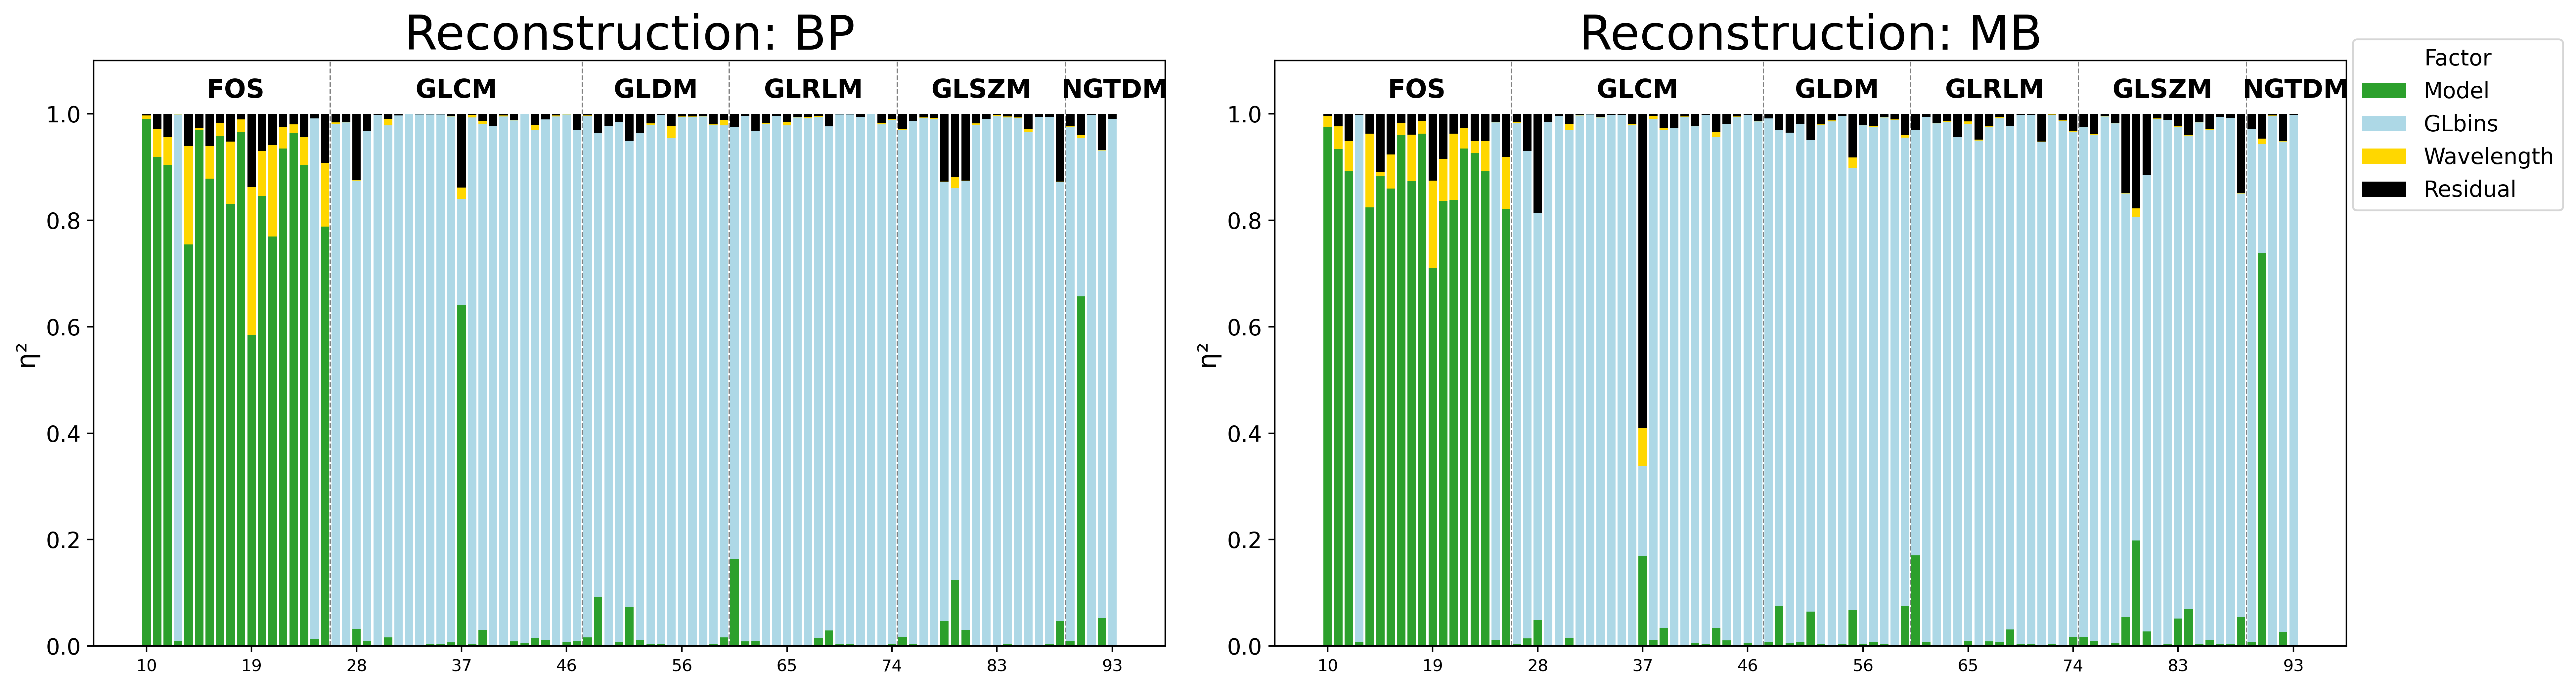

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Color palette (fully consistent)
colors = {
    "Model": "#2ca02c",          # green
    "GLbins": "#ADD8E6",         # light blue (for consistency even if not used here)
    "Wavelength": "#FFD700",     # gold
    "Reconstruction": "#800080", # purple
    "Residual": "#000000"        # black
}

# Factors
factors = ["Model", "GLbins", "Wavelength", "Residual"]

# Extract group + shortname
def extract_group_and_shortname(feature):
    if 'firstorder' in feature:
        group = 'FOS'
        short = feature.split('firstorder_')[-1]
    elif 'glcm' in feature:
        group = 'GLCM'
        short = feature.split('glcm_')[-1]
    elif 'gldm' in feature:
        group = 'GLDM'
        short = feature.split('gldm_')[-1]
    elif 'glrlm' in feature:
        group = 'GLRLM'
        short = feature.split('glrlm_')[-1]
    elif 'glszm' in feature:
        group = 'GLSZM'
        short = feature.split('glszm_')[-1]
    elif 'ngtdm' in feature:
        group = 'NGTDM'
        short = feature.split('ngtdm_')[-1]
    else:
        group = 'Other'
        short = feature
    return group, short

# Recon types
recon_types = ['BP', 'MB']

# Create 1x2 grid
fig, axs = plt.subplots(1, 2, figsize=(20, 5.3), dpi=400)

for i, recon in enumerate(recon_types):
    df = pd.read_csv(f'../data/Photoacoustic_Study/csv/anova_eta2_reconstruction_{recon}.csv', index_col=0)

    df['Group'], df['ShortName'] = zip(*df.index.map(extract_group_and_shortname))
    df_sorted = df.sort_values(by=['Group', 'ShortName'])
    groups = df_sorted['Group'].tolist()

    group_boundaries = []
    prev_group = groups[0]
    for idx, group in enumerate(groups):
        if group != prev_group:
            group_boundaries.append(idx)
            prev_group = group

    ax = axs[i]
    bottom = pd.Series(0, index=df_sorted.index)

    for factor in factors:
        ax.bar(range(len(df_sorted)), df_sorted[factor], bottom=bottom, color=colors[factor], label=factor)
        bottom += df_sorted[factor]

    ax.set_xticks(np.linspace(0, len(df_sorted)-1, 10, dtype=int))
    ax.set_xticklabels(np.linspace(10, 93, 10, dtype=int), fontsize=9)
    ax.tick_params(axis='y', labelsize=12)

    for boundary in group_boundaries:
        ax.axvline(x=boundary - 0.5, color='grey', linestyle='--', linewidth=0.7)

    group_names = ['FOS', 'GLCM', 'GLDM', 'GLRLM', 'GLSZM', 'NGTDM']
    for group in group_names:
        indices = [j for j, g in enumerate(groups) if g == group]
        if indices:
            center_pos = (indices[0] + indices[-1]) / 2
            if group == 'NGTDM':
                center_pos += 2.2
            ax.text(center_pos, 1.02, group, ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_ylim(0, 1.1)
    ax.set_ylabel("η²", fontsize=14)
    ax.set_title(f"Reconstruction: {recon}", fontsize=26)

# Shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.975, 0.95), fontsize=12, title="Factor", title_fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("../plots/ANOVA_plots/ANOVA_reconstruction.png", dpi=400)
plt.show()


### 5 FOLD ANALYSIS

In [ ]:
import pandas as pd
from tabulate import tabulate

# Load Skewness CSVs
df_summary_skew = pd.read_csv("../dataPhotoacoustic_Study/csv/eta2_summary_skewness.csv", index_col=0)
df_folds_skew = pd.read_csv("../data/Photoacoustic_Study/csv/eta2_folds_skewness.csv", index_col=0)

# Display η² per fold
print("\n--- η² per Fold for Skewness ---")
print(tabulate(df_folds_skew, headers="keys", tablefmt="grid", floatfmt=".2f"))

# Display summary stats (mean ± std, CoV)
df_summary_skew_rounded = df_summary_skew.copy()
df_summary_skew_rounded["Mean ± Std"] = (
    df_summary_skew["Mean"].round(2).astype(str) + " ± " + df_summary_skew["Std"].round(2).astype(str)
)
df_summary_skew_rounded["CoV"] = df_summary_skew["CoV"].round(2)

print("\n--- Summary Statistics for Skewness η² ---")
print(tabulate(df_summary_skew_rounded[["Mean ± Std", "CoV"]], headers="keys", tablefmt="grid"))



--- η² per Fold for Skewness ---
+-------+---------+----------+--------------+------------------+------------+
| Row   |   Model |   GLbins |   Wavelength |   Reconstruction |   Residual |
+=======+=========+==========+==============+==================+============+
| Fold1 |    0.91 |     0.00 |         0.01 |             0.05 |       0.03 |
+-------+---------+----------+--------------+------------------+------------+
| Fold2 |    0.84 |     0.00 |         0.02 |             0.08 |       0.05 |
+-------+---------+----------+--------------+------------------+------------+
| Fold3 |    0.91 |     0.00 |         0.03 |             0.03 |       0.03 |
+-------+---------+----------+--------------+------------------+------------+
| Fold4 |    0.79 |     0.00 |         0.03 |             0.10 |       0.08 |
+-------+---------+----------+--------------+------------------+------------+
| Fold5 |    0.86 |     0.00 |         0.02 |             0.06 |       0.05 |
+-------+---------+----------+

In [ ]:
import pandas as pd
from tabulate import tabulate

# Load CSVs
df_summary = pd.read_csv("../data/Photoacoustic_Study/csv/eta2_summary_Kurtosis.csv", index_col=0)
df_folds = pd.read_csv("../data/Photoacoustic_Study/csv/eta2_folds_Kurtosis.csv", index_col=0)

# Display per-fold η² values
print("\n--- η² per Fold for Kurtosis ---")
print(tabulate(df_folds, headers='keys', tablefmt='grid', floatfmt=".2f"))

# Display summary statistics (mean ± std, CoV)
print("\n--- Summary Statistics for Kurtosis η² ---")
df_summary_rounded = df_summary.copy()
df_summary_rounded["Mean ± Std"] = df_summary["Mean"].round(2).astype(str) + " ± " + df_summary["Std"].round(2).astype(str)
df_summary_rounded["CoV"] = df_summary["CoV"].round(2)
print(tabulate(df_summary_rounded[["Mean ± Std", "CoV"]], headers='keys', tablefmt='grid'))



--- η² per Fold for Kurtosis ---
+-------+---------+----------+--------------+------------------+------------+
| Row   |   Model |   GLbins |   Wavelength |   Reconstruction |   Residual |
+=======+=========+==========+==============+==================+============+
| Fold1 |    0.87 |     0.00 |         0.00 |             0.09 |       0.04 |
+-------+---------+----------+--------------+------------------+------------+
| Fold2 |    0.72 |     0.00 |         0.01 |             0.17 |       0.10 |
+-------+---------+----------+--------------+------------------+------------+
| Fold3 |    0.85 |     0.00 |         0.01 |             0.06 |       0.08 |
+-------+---------+----------+--------------+------------------+------------+
| Fold4 |    0.50 |     0.00 |         0.01 |             0.25 |       0.24 |
+-------+---------+----------+--------------+------------------+------------+
| Fold5 |    0.69 |     0.00 |         0.01 |             0.15 |       0.14 |
+-------+---------+----------+